In [1]:
import torch
import numpy as np
import pandas as pd
from epiweeks import Week
import seaborn as sns
import preprocess_data as prep
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec

pd.options.mode.chained_assignment = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

regioes_estados = {
        'Sul': ['SC', 'PR', 'RS'],
        'Sudeste': ['SP', 'MG', 'RJ', 'ES'],
        'Nordeste': ['BA', 'CE', 'PE', 'PB', 'PI', 'RN', 'MA', 'AL', 'SE'],
        'Centro-Oeste': ['DF', 'MT', 'MS', 'GO'],
        'Norte': ['RO', 'AC', 'AM', 'RR', 'PA', 'AP', 'TO']
    } 
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

columns_to_normalize = ['casos','epiweek', 'biome', 'enso']

predict_n = 52
max_epiweek = 22
    
boxcox = False

TEST_YEAR = 2026

In [2]:
batch_size = 1
doenca = 'dengue'
min_delta = 0.0
patience= 20
lr = 5e-4
min_year = 2015
model_name = 'mix_22_26'

filename = f'./data/{doenca}.csv.gz'

df = prep.load_cases_data(filename)

df = df.loc[df.epiweek <= int(f'{TEST_YEAR}{max_epiweek}')]

enso = prep.load_enso_weekly(filename='data/enso_weekly_forecast_up_25_07.csv')

enso_neutro = prep.load_enso_weekly(filename='data/enso_weekly_neutro_up_25_07.csv')

Make figures: 

In [3]:
df.epiweek.max()

np.int64(202622)

In [4]:
def make_figure(ax, df, region, TEST_YEAR, model_name): 

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_preds = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv')
    df_preds.date = pd.to_datetime(df_preds.date)

    df_preds_neutro = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_neutro_{model_name}.csv')
    df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)


    df_st_plot = df_reg.loc[(df_reg.epiweek >= 202501)]

    df_st_plot = df_st_plot.resample('W-SUN')[['casos']].sum()

    ax.plot(df_st_plot.index, df_st_plot.casos, color = 'black', label = 'Observado')

    ax.plot(df_preds.date, df_preds.pred, color = 'tab:red', label = 'El niño')

    ax.fill_between(df_preds.date, df_preds.lower_80, df_preds.upper_80, alpha=0.1,  color = 'tab:red')

    ax.plot(df_preds_neutro.date, df_preds_neutro.pred, color = 'tab:green', label = 'Neutro')

    ax.fill_between(df_preds_neutro.date, df_preds_neutro.lower_80, df_preds_neutro.upper_80, color = 'tab:green', alpha = 0.1)

    ax.set_title(region)
    ax.legend()
    ax.set_ylabel('Casos prováveis')
    ax.grid()


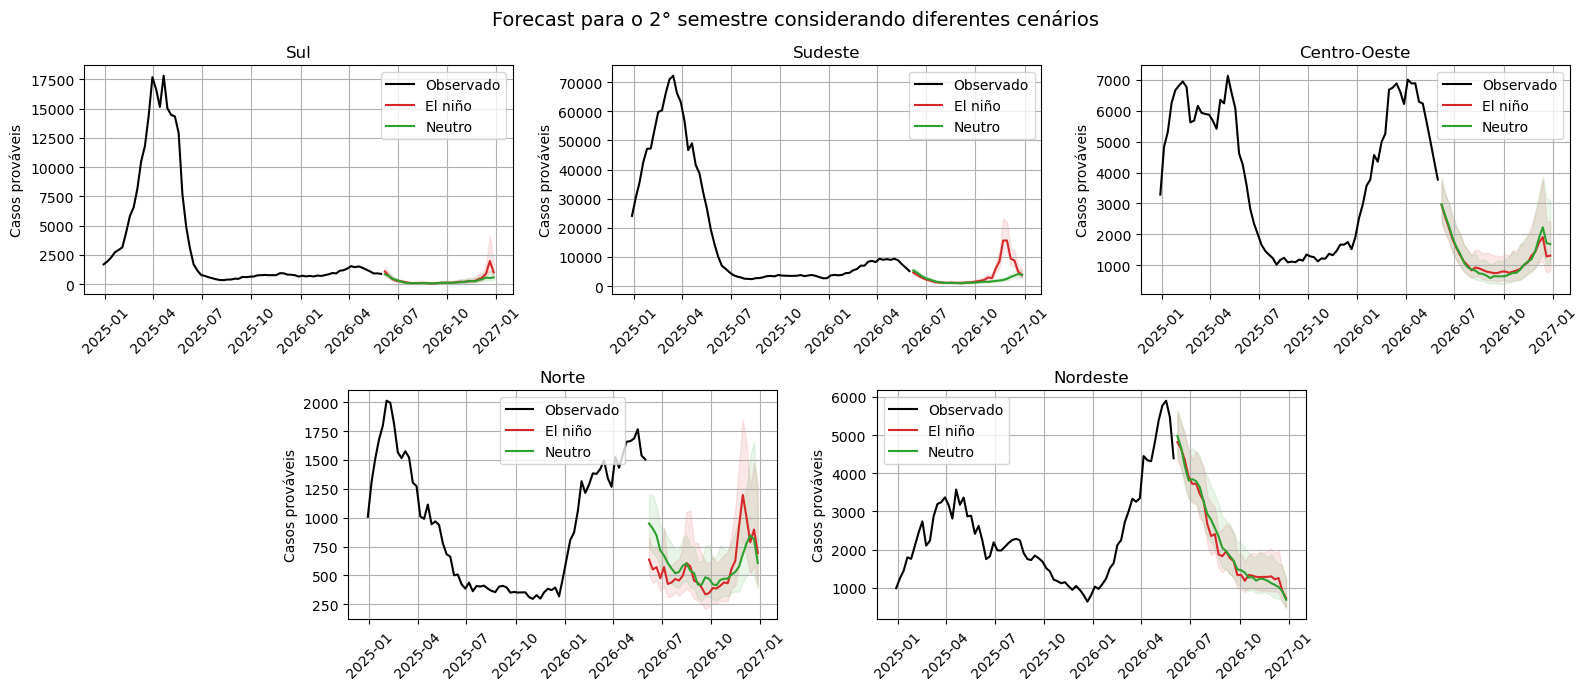

In [5]:
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 6, figure=fig)

# First row with three boxplots
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])

# Second row with two boxplots
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])


for r, ax in zip(['Sul', 'Sudeste', 'Centro-Oeste', 'Norte', 'Nordeste'], [ax1,ax2,ax3,ax4,ax5]): 

    make_figure(ax, df, r, TEST_YEAR, model_name)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Forecast para o 2° semestre considerando diferentes cenários', fontsize = 14)
plt.tight_layout()

plt.savefig(f'figures/forecast_all_regions_{doenca}_enso_median_2.png', dpi = 400, bbox_inches = 'tight')
plt.show()

In [6]:
def make_figure2(ax, df, region, TEST_YEAR, model_name): 

    df_reg = df.loc[df.uf.isin(regioes_estados[region])]
    df_reg = df_reg.loc[df_reg.index >= pd.to_datetime(Week(2015,1).startdate())]

    df_preds = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_{model_name}.csv')
    df_preds.date = pd.to_datetime(df_preds.date)

    df_preds_neutro = pd.read_csv(f'predictions/preds_{doenca}_{region}_{TEST_YEAR}_neutro_{model_name}.csv')
    df_preds_neutro.date = pd.to_datetime(df_preds_neutro.date)

    df_st_plot = df_reg.resample('W-SUN')[['casos']].sum()
    df_st_plot['year'] = df_st_plot.index.year
    df_st_plot['week'] = [Week.fromdate(x).week for x in df_st_plot.index]

    for year in np.arange(2020, 2026):

        df_reg_y = df_st_plot.loc[(df_st_plot.year == year) & (df_st_plot.week >= 23) & (df_st_plot.week <= 52)]
        
        ax.plot(df_preds.date, df_reg_y.casos, color = 'black', alpha = 0.25)

    ax.plot([], [], color = 'black', alpha = 0.25, label = '2020-2025')

    ax.plot(df_preds.date, df_preds.pred, color = 'tab:red', label = 'El niño')

    ax.fill_between(df_preds.date, df_preds.lower_80, df_preds.upper_80, alpha=0.1,  color = 'tab:red')

    ax.plot(df_preds_neutro.date, df_preds_neutro.pred, color = 'tab:green', label = 'Neutro')

    ax.fill_between(df_preds_neutro.date, df_preds_neutro.lower_80, df_preds_neutro.upper_80, color = 'tab:green', alpha = 0.1)

    ax.set_title(region)
    #ax.legend()
    ax.set_ylabel('Casos prováveis')
    ax.set_ylim([0, 1.25*max( df_preds.upper_80)])

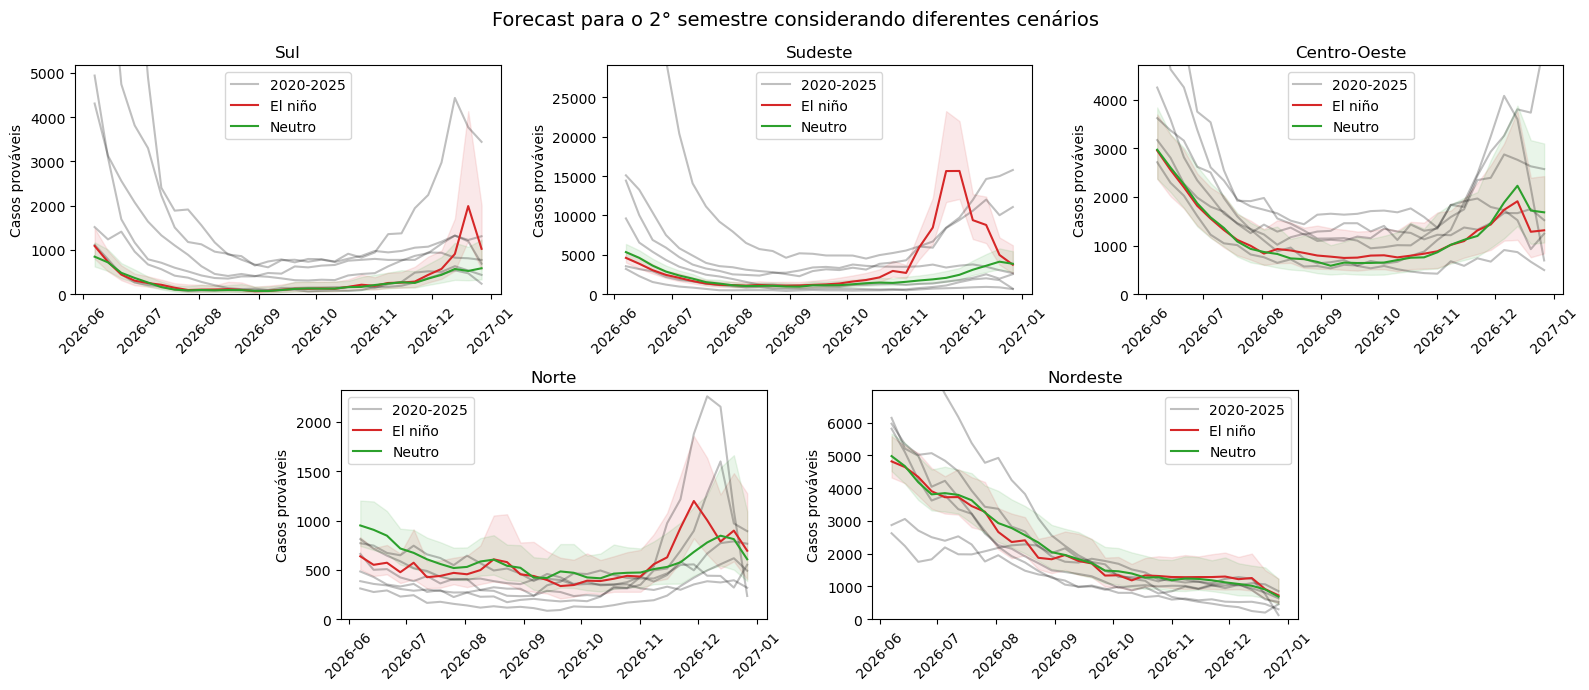

In [7]:
fig = plt.figure(figsize=(16, 7))
gs = gridspec.GridSpec(2, 6, figure=fig)

# First row with three boxplots
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])

# Second row with two boxplots
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])


for r, ax in zip(['Sul', 'Sudeste', 'Centro-Oeste', 'Norte', 'Nordeste'], [ax1,ax2,ax3,ax4,ax5]): 

    make_figure2(ax, df, r, TEST_YEAR, model_name)
    ax.tick_params(axis='x', rotation=45)
    ax.legend()

plt.suptitle('Forecast para o 2° semestre considerando diferentes cenários', fontsize = 14)
plt.tight_layout()

plt.savefig(f'figures/forecast_all_regions_{doenca}_2_semester_{model_name}.png', dpi = 400, bbox_inches = 'tight')
plt.show()

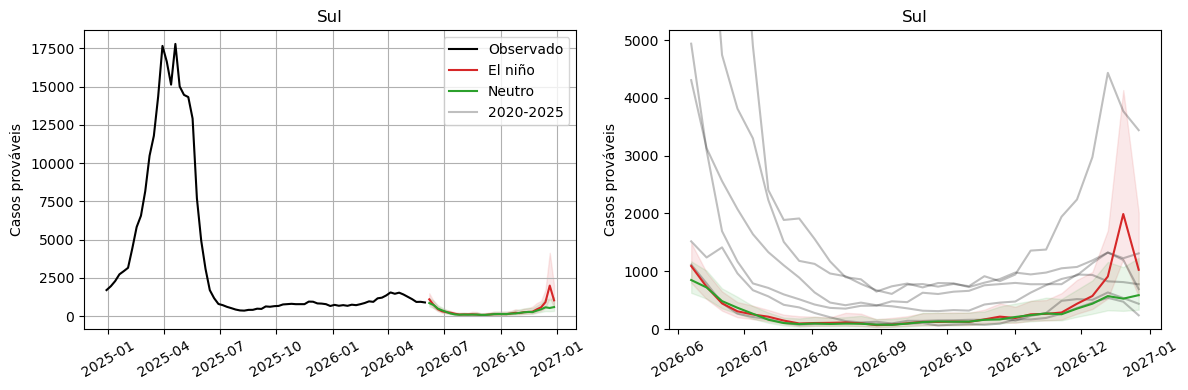

In [8]:
_,ax = plt.subplots(1,2, figsize = (12, 4), sharey = False)
r = 'Sul'
make_figure(ax[0], df, r, TEST_YEAR, model_name)
ax[0].tick_params(axis='x', rotation=30)

make_figure2(ax[1], df, r, TEST_YEAR, model_name)
ax[1].tick_params(axis='x', rotation=30)


handles1, labels1 = ax[0].get_legend_handles_labels()
handles2, labels2 = ax[1].get_legend_handles_labels()

# combina
handles = handles1 + handles2
labels = labels1 + labels2

# remove duplicados preservando ordem
unique = dict(zip(labels, handles))

# cria legenda única
ax[0].legend(unique.values(), unique.keys(), loc="best")


plt.tight_layout()
plt.show()

### Total cases: 

In [9]:
df_end = pd.read_csv(f'predictions/total_cases_all_regions_{doenca}_{model_name}.csv')

df_end.head()

,regional_geocode,pred,lower_50,upper_50,lower_80,upper_80,lower_90,upper_90,lower_95,upper_95,model
0,Sul,12266.307045,10972.455759,13671.189851,10164.631336,15494.108214,9665.158285,17111.429485,9386.985927,18623.770136,El niño
1,Sul,9302.139993,8433.338635,10236.203208,7886.261426,11568.559198,7519.489123,12482.132993,7284.192060,13623.530002,Neutro
2,Sudeste,121837.569256,115160.486636,129591.674870,109030.749822,138613.881663,106757.702423,144851.173540,104385.351255,154309.231840,El niño
3,Sudeste,66176.032209,63512.683372,69887.054655,61375.546467,72435.009481,59962.543148,75023.034166,59184.669023,76488.258630,Neutro
4,Nordeste,67935.604564,65630.114416,70618.028733,63743.362617,73422.083134,62463.076157,74594.876233,61742.445699,75611.692926,El niño


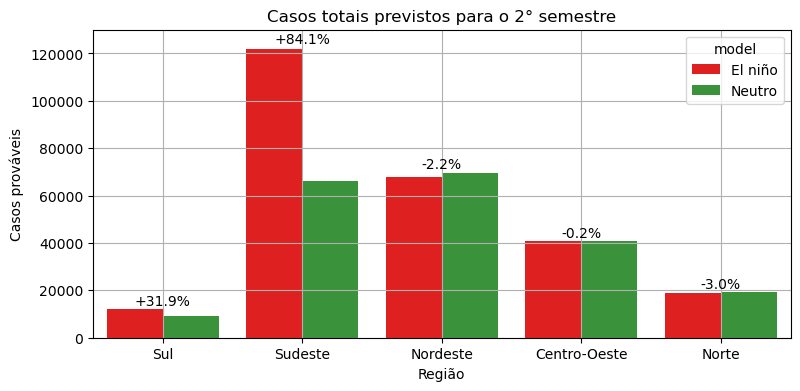

In [13]:
_,ax = plt.subplots(figsize = (9, 4))

sns.barplot(data=df_end, ax=ax, hue='model', x='regional_geocode', y = 'pred', palette=['red', 'tab:green'])

for i, region in enumerate(df_end['regional_geocode'].unique()):

    df_r = df_end[df_end['regional_geocode'] == region]

    v1 = df_r.loc[df_r.model == 'Neutro']['pred'].values[0]
    v2 = df_r.loc[df_r.model == 'El niño']['pred'].values[0]

    pct = 100 * (v2 - v1) / v1

    y = max(v1, v2)

    ax.text(
        i,                  # centro do grupo
        y * 1.01,           # um pouco acima da barra mais alta
        f'{pct:+.1f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )


#ax.set_ylim([0, 210000])
ax.set_ylim([0, 130000])

ax.grid()
ax.set_xlabel('Região')
ax.set_ylabel('Casos prováveis')
ax.set_title('Casos totais previstos para o 2° semestre')
plt.savefig(f'figures/total_cases_all_regions_{doenca}.png', dpi = 400, bbox_inches = 'tight')
plt.show()